This notebook tests the ResNet-34 architecture on the all dataset.

The ResNet-34 model utilizes pre-trained weights.

Model Parameters:
* optimizer = Adam [lr = 0.00001, weight_decay=0.01]
* loss function = Cross Entropy Loss (weights = None)

Early stopping is applied to combat overfitting. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/All/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/All
cuda


In [3]:
train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers=8 )
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers=8)

Train set length: 3241
Test set length: 404
Validation set length: 408


In [4]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
{'0': 49, '1': 51, '2': 47, '3': 52, '4': 48, '5': 53, '6': 104}
{'0': 50, '1': 51, '2': 48, '3': 52, '4': 48, '5': 54, '6': 105}


In [5]:
# @title Importing ResNet34 model, using DEFAULT weights
import torchvision.models as models
emotionTotal = 7
myModel = models.resnet34(weights = 'DEFAULT')
# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.fc.parameters():
    param.requires_grad = True

for param in myModel.layer4.parameters():
    param.requires_grad = True
    
myModel.fc = nn.Sequential(nn.Linear(myModel.fc.in_features,emotionTotal))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)
# print(device)


cuda


In [ ]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.001, momentum=0.9, weight_decay= 0.01)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)
lr_scheduler_a = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', patience=4, factor=0.1)
train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, lr_scheduler_a, 100, criterion, name = 'All/Transfer Learning/All ResNet34.pth')
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')


100%|██████████| 203/203 [00:04<00:00, 46.23it/s]


Epoch 1/250, Training Loss: 1.6720, Validation Loss: 1.2668
Epoch 1/250, Training Acc: 34.88984674329502, Validation Accuracy: 58.41346153846154


100%|██████████| 203/203 [00:04<00:00, 48.77it/s]


Epoch 2/250, Training Loss: 1.0439, Validation Loss: 0.8968
Epoch 2/250, Training Acc: 65.65407772304323, Validation Accuracy: 72.83653846153845


100%|██████████| 203/203 [00:04<00:00, 48.30it/s]


...

Epoch 25/250, Training Loss: 0.0936, Validation Loss: 0.4221
Epoch 25/250, Training Acc: 97.42063492063492, Validation Accuracy: 86.0576923076923


100%|██████████| 203/203 [00:04<00:00, 48.05it/s]


Epoch 26/250, Training Loss: 0.0825, Validation Loss: 0.4074
Epoch 26/250, Training Acc: 98.00561029009305, Validation Accuracy: 87.01923076923077


100%|██████████| 203/203 [00:04<00:00, 47.49it/s]


Model saved successfully!
Test Loss: 0.4345, Test Accuracy: 86.52%


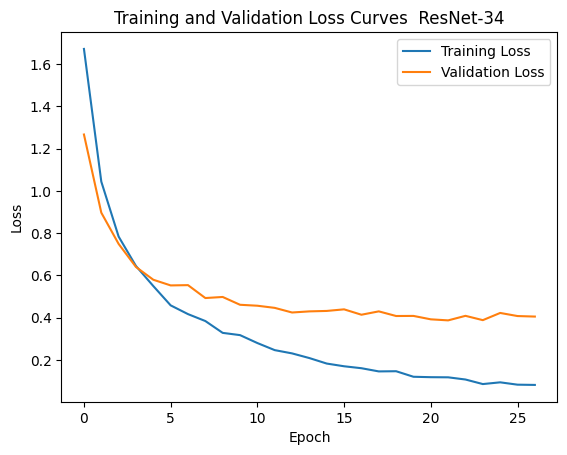

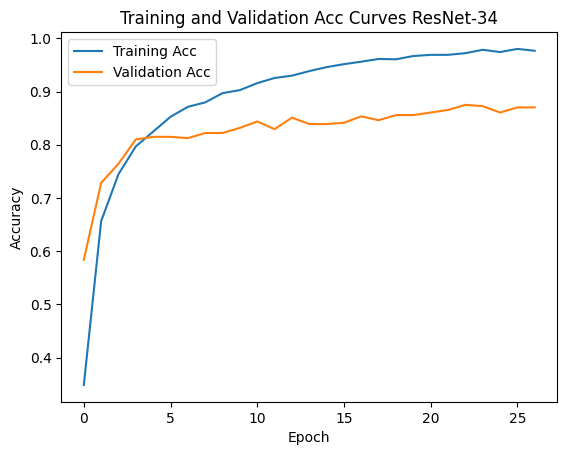

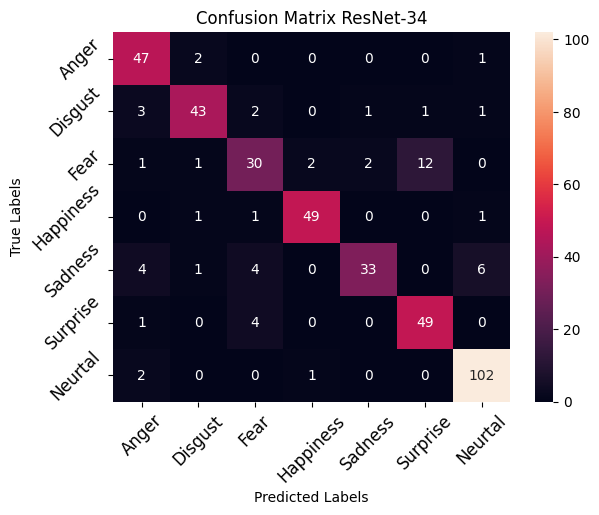

              precision    recall  f1-score   support

       Anger     0.8103    0.9400    0.8704        50
     Disgust     0.8958    0.8431    0.8687        51
        Fear     0.7317    0.6250    0.6742        48
   Happiness     0.9423    0.9423    0.9423        52
     Sadness     0.9167    0.6875    0.7857        48
    Surprise     0.7903    0.9074    0.8448        54
     Neurtal     0.9189    0.9714    0.9444       105

    accuracy                         0.8652       408
   macro avg     0.8580    0.8453    0.8472       408
weighted avg     0.8664    0.8652    0.8620       408



In [7]:
lossPlot(train_losses, val_losses, ' ResNet-34')
accuracyPlot(train_accuracy, val_accuracy, ' ResNet-34')
confusionMatrixPlot(y_true, y_pred, ' ResNet-34')